# Cuencas de atracción · Traducción a Python

Este notebook reproduce en Python las tres variantes del cálculo de cuencas de atracción presentadas en el notebook de Wolfram Mathematica.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


def newton_step(z):
    z = np.asarray(z, dtype=np.complex128)
    numerator = z**3 - 1
    denominator = 3 * z**2
    update = np.zeros_like(z)
    np.divide(numerator, denominator, out=update, where=denominator != 0)
    return z - update


def schroeder_step(z):
    z = np.asarray(z, dtype=np.complex128)
    target = 3 + 1j
    pz = (z**2 - 1) * (z - target)
    dp = 2 * z * (z - target) + (z**2 - 1)
    d2p = 6 * z - 2 * target  # Corregido: p''(z) = 6z - 2(3+i)
    
    lp = np.zeros_like(z)
    denom_lp = dp**2
    np.divide(pz * d2p, denom_lp, out=lp, where=denom_lp != 0)
    
    ratio = np.zeros_like(z)
    np.divide(pz, dp, out=ratio, where=dp != 0)
    
    correction = np.zeros_like(z)
    np.divide(ratio, 1 - lp, out=correction, where=(1 - lp) != 0)
    
    return z - correction

# def schroeder_step(z):
#     z = np.asarray(z, dtype=np.complex128)
#     target = 3 + 1j
#     pz = (z**2 - 1) * (z - target)
#     dp = 2 * z * (z - target) + (z**2 - 1)
#     d2p = 2 * (z - target) + 2 * z
#     ratio = np.zeros_like(z)
#     np.divide(pz, dp, out=ratio, where=dp != 0)
#     lp = np.zeros_like(z)
#     denom_lp = dp**2
#     np.divide(pz * d2p, denom_lp, out=lp, where=denom_lp != 0)
#     correction = np.zeros_like(z)
#     np.divide(ratio, 1 - lp, out=correction, where=(1 - lp) != 0)
#     return z - correction


def root_position(z_values, roots, labels, tol=1e-6):
    z = np.asarray(z_values)
    distances = np.abs(z[..., None] - roots)
    closest = distances.argmin(axis=-1)
    min_dist = distances.min(axis=-1)
    result = np.zeros(z.shape, dtype=int)
    mask = min_dist < tol
    result[mask] = labels[closest[mask]]
    return result


def compute_basins(step_func, roots, labels, x_range, y_range, points, limit, tol=1e-6):
    xs = np.linspace(x_range[0], x_range[1], points)
    ys = np.linspace(y_range[1], y_range[0], points)
    grid = xs[None, :] + 1j * ys[:, None]
    current = grid.copy()
    iter_counts = np.zeros(grid.shape, dtype=int)
    root_ids = np.zeros(grid.shape, dtype=int)

    for _ in range(limit):
        active = root_ids == 0
        if not np.any(active):
            break
        iter_counts[active] += 1
        updated = step_func(current[active])
        current[active] = updated
        new_ids = root_position(updated, roots, labels, tol=tol)
        if np.any(new_ids):
            stored = root_ids[active]
            mask = new_ids > 0
            stored[mask] = new_ids[mask]
            root_ids[active] = stored

    values = root_ids.astype(float) + iter_counts / (limit + 0.001)
    return xs, ys, root_ids, iter_counts, values


def cmyk_to_rgb(c, m, y, k):
    c = np.clip(np.asarray(c, dtype=float), 0.0, 1.0)
    m = np.clip(np.asarray(m, dtype=float), 0.0, 1.0)
    y = np.clip(np.asarray(y, dtype=float), 0.0, 1.0)
    k = np.clip(np.asarray(k, dtype=float), 0.0, 1.0)
    r = 1.0 - np.minimum(1.0, c + k)
    g = 1.0 - np.minimum(1.0, m + k)
    b = 1.0 - np.minimum(1.0, y + k)
    return np.stack([r, g, b], axis=-1)


def colors_case1(values):
    labels = values.astype(int)
    rgb = np.zeros(values.shape + (3,), dtype=float)
    rgb[labels == 3] = (1.0, 0.0, 0.0)
    rgb[labels == 2] = (0.0, 1.0, 0.0)
    rgb[labels == 1] = (0.0, 0.0, 1.0)
    return rgb


def colors_case2(values):
    labels = values.astype(int)
    frac = np.modf(values)[0]
    pp = 0.4 * frac
    rgb = np.zeros(values.shape + (3,), dtype=float)
    mask3 = labels == 3
    mask2 = labels == 2
    mask1 = labels == 1
    if np.any(mask3):
        rgb[mask3] = cmyk_to_rgb(0.6 + pp[mask3], 0.0, 0.0, 2 * pp[mask3])
    if np.any(mask2):
        rgb[mask2] = cmyk_to_rgb(0.0, 0.6 + pp[mask2], 0.0, 2 * pp[mask2])
    if np.any(mask1):
        rgb[mask1] = cmyk_to_rgb(0.0, 0.0, 0.6 + pp[mask1], 2 * pp[mask1])
    return rgb


def show_fractal(xs, ys, colors, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(colors, origin='upper', extent=[xs.min(), xs.max(), ys.min(), ys.max()])
    ax.set_xlabel('Re(z)')
    ax.set_ylabel('Im(z)')
    ax.set_title(title)
    plt.show()



## Caso 1 · Método de Newton para $z^3 - 1$ (versión sin intensidad)

Repetimos la configuración del notebook original: 25 iteraciones máximas y una malla de 64×64 puntos en $[-1.5,1.5]^2$. El color solo depende de la raíz alcanzada.


Iteraciones máximas registradas: 25


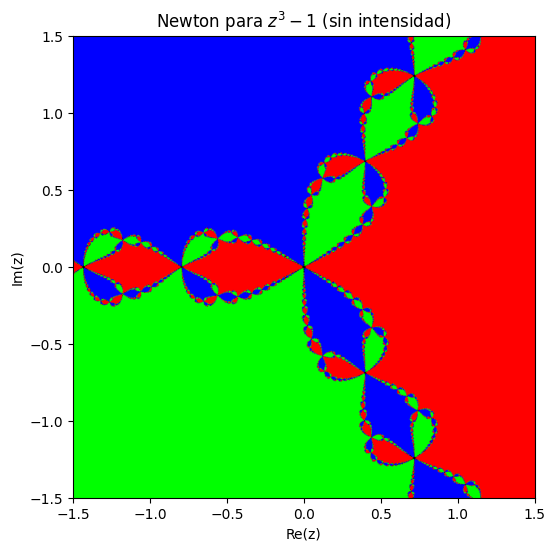

In [2]:

roots_case1 = np.array([1 + 0j,
                        -0.5 - 0.8660254037844386j,
                        -0.5 + 0.8660254037844386j], dtype=np.complex128)
labels_case1 = np.array([3, 2, 1])
x_range = (-1.5, 1.5)
y_range = (-1.5, 1.5)
points_case1 = 1024
lim_iterations = 25

xs1, ys1, root_ids1, counts1, values1 = compute_basins(
    newton_step,
    roots_case1,
    labels_case1,
    x_range,
    y_range,
    points_case1,
    lim_iterations,
)

print("Iteraciones máximas registradas:", counts1.max())
colors1 = colors_case1(values1)
show_fractal(xs1, ys1, colors1, "Newton para $z^3 - 1$ (sin intensidad)")



## Caso 2 · Método de Newton para $z^3 - 1$ (versión con intensidad)

Volvemos a generar las cuencas con la misma región pero incorporamos la intensidad de color basada en el número de iteraciones, siguiendo la regla $0.4 \cdot \operatorname{fract}(p)$ del notebook original.


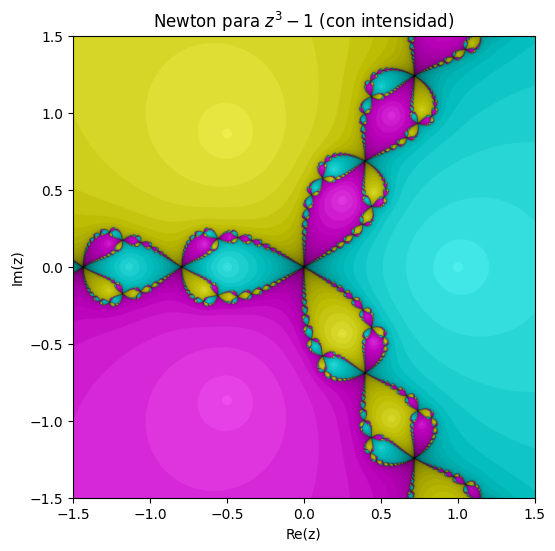

Imagen exportada a: img/newton_Z^3-1.png


In [5]:

import os
points_case2 = 1024*2  # mayor resolución para apreciar la intensidad
xs2, ys2, root_ids2, counts2, values2 = compute_basins(
    newton_step,
    roots_case1,
    labels_case1,
    x_range,
    y_range,
    points_case2,
    lim_iterations,
)

colors2 = colors_case2(values2)
show_fractal(xs2, ys2, colors2, "Newton para $z^3 - 1$ (con intensidad)")

# Crear carpeta img si no existe
os.makedirs('img', exist_ok=True)

# Exportar sin título pero con escalas en los ejes (sin etiquetas)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(colors2, origin='upper', extent=[xs2.min(), xs2.max(), ys2.min(), ys2.max()])
ax.set_xlabel('')  # Sin etiqueta en eje x
ax.set_ylabel('')  # Sin etiqueta en eje y
ax.tick_params(axis='both', which='both', length=5, width=1)  # Mostrar ticks
plt.savefig('img/newton_Z^3-1.png', dpi=300, bbox_inches='tight')
plt.close()

print("Imagen exportada a: img/newton_Z^3-1.png")



## Caso 3 · Método de Schröder para $(z^2-1)(z-3-i)$

Implementamos la iteración de Schröder descrita en el notebook y dibujamos las cuencas con intensidad de color:
* Dominio: $x \in [-5, 8]$, $y \in [-7, 6]$
* 25 iteraciones como máximo
* Malla de 128×128 puntos


Iteraciones máximas registradas: 25


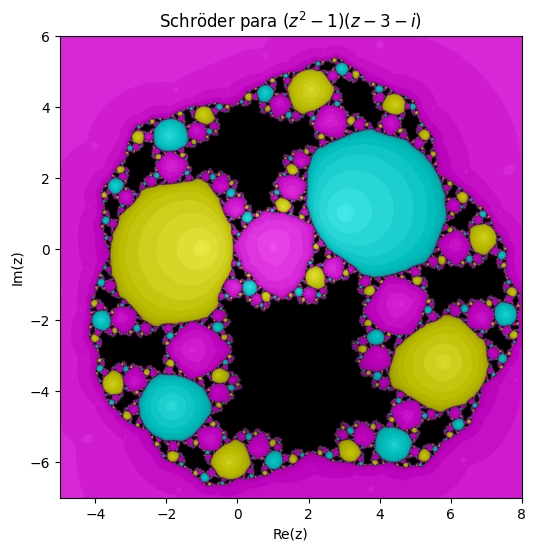

In [20]:

roots_case3 = np.array([3 + 1j,
                        1 + 0j,
                        -1 + 0j], dtype=np.complex128)
labels_case3 = np.array([3, 2, 1])
x_range_case3 = (-5.0, 8.0)
y_range_case3 = (-7.0, 6.0)
points_case3 = 1024*2

xs3, ys3, root_ids3, counts3, values3 = compute_basins(
    schroeder_step,
    roots_case3,
    labels_case3,
    x_range_case3,
    y_range_case3,
    points_case3,
    lim_iterations,
)

print("Iteraciones máximas registradas:", counts3.max())
colors3 = colors_case2(values3)
show_fractal(xs3, ys3, colors3, "Schröder para $(z^2 - 1)(z - 3 - i)$")



### Análisis simbólico de la iteración de Schröder

Reproducimos los cálculos simbólicos del notebook: puntos fijos de la iteración, ceros de $p'(z)$ y la magnitud de $s'(z)$ en esos puntos.


In [17]:

z = sp.symbols('z')
p = (z**2 - 1) * (z - (3 + sp.I))
p_prime = sp.diff(p, z)
p_second = sp.diff(p_prime, z)
lp = sp.simplify(p * p_second / (p_prime**2))
s_expr = sp.simplify(z - (p / p_prime) / (1 - lp))
s_prime_expr = sp.simplify(sp.diff(s_expr, z))

fixed_points = sp.nroots(sp.expand(s_expr - z))
critical_points = sp.nroots(sp.expand(p_prime))

print("Puntos fijos de s(z):")
for fp in fixed_points:
    print(f"  {complex(fp):.12f}")

print("Ceros de p'(z):")
for cp in critical_points:
    print(f"  {complex(cp):.12f}")

print("Derivada de s en los ceros de p':")
derivative_values = []
for cp in critical_points:
    value = complex(sp.N(s_prime_expr.subs(z, cp)))
    derivative_values.append(value)
    print(f"  s'({complex(cp):.12f}) = {value:.12f}  |s'| = {abs(value):.12f}")

product_magnitude = abs(derivative_values[0] * derivative_values[1])
print(f"|s'(z_1) * s'(z_2)| = {product_magnitude:.12f}")


MultivariatePolynomialError: Cannot compute numerical roots of Poly((3 + I)*z**4*(1/(3*z**4 - 12*z**3 - 4*I*z**3 + 16*z**2 + 12*I*z**2 - 12*z - 4*I*z + 17 + 12*I)) + 4*z**3*(1/(3*z**4 - 12*z**3 - 4*I*z**3 + 16*z**2 + 12*I*z**2 - 12*z - 4*I*z + 17 + 12*I)) + (-30 - 10*I)*z**2*(1/(3*z**4 - 12*z**3 - 4*I*z**3 + 16*z**2 + 12*I*z**2 - 12*z - 4*I*z + 17 + 12*I)) + (32 + 24*I)*z*(1/(3*z**4 - 12*z**3 - 4*I*z**3 + 16*z**2 + 12*I*z**2 - 12*z - 4*I*z + 17 + 12*I)) - z + (3 + I)*(1/(3*z**4 - 12*z**3 - 4*I*z**3 + 16*z**2 + 12*I*z**2 - 12*z - 4*I*z + 17 + 12*I)), z, 1/(3*z**4 - 12*z**3 - 4*I*z**3 + 16*z**2 + 12*I*z**2 - 12*z - 4*I*z + 17 + 12*I), domain='ZZ_I')

Iteraciones máximas registradas (extra): 25


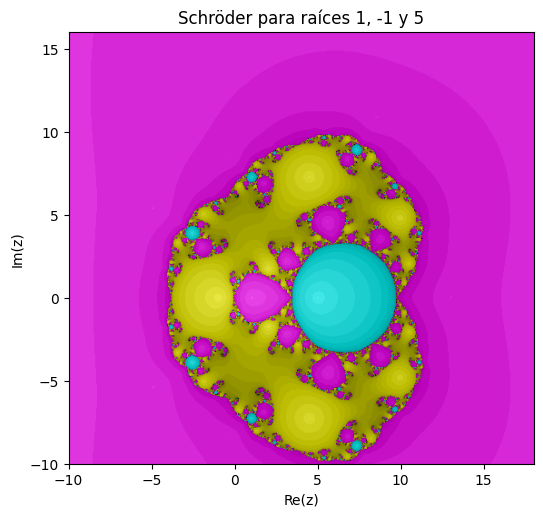

: 

In [ ]:
## Caso extra · Schröder para raíces 1, -1 y 5
import os

def schroeder_step_roots_1_m1_5(z):
    z = np.asarray(z, dtype=np.complex128)
    target = 5 + 0j
    pz = (z**2 - 1) * (z - target)
    dp = 2 * z * (z - target) + (z**2 - 1)
    d2p = 6 * z - 2 * target  # p''(z) = 6z - 2*5 = 6z - 10
    lp = np.zeros_like(z)
    denom_lp = dp**2
    np.divide(pz * d2p, denom_lp, out=lp, where=denom_lp != 0)
    ratio = np.zeros_like(z)
    np.divide(pz, dp, out=ratio, where=dp != 0)
    correction = np.zeros_like(z)
    np.divide(ratio, 1 - lp, out=correction, where=(1 - lp) != 0)
    return z - correction

# Definimos raíces y parámetros de la malla
roots_extra = np.array([5 + 0j, 1 + 0j, -1 + 0j], dtype=np.complex128)
labels_extra = np.array([3, 2, 1])
x_range_extra = (-10.0, 18.0)
y_range_extra = (-10.0, 16.0)
points_extra = 512  # moderada resolución; sube si tu equipo lo permite
lim_extra = 25

xs_e, ys_e, root_ids_e, counts_e, values_e = compute_basins(
    schroeder_step_roots_1_m1_5,
    roots_extra,
    labels_extra,
    x_range_extra,
    y_range_extra,
    points_extra,
    lim_extra,
)

print("Iteraciones máximas registradas (extra):", counts_e.max())
colors_e = colors_case2(values_e)

# Crear carpeta img si no existe
os.makedirs('img', exist_ok=True)

# Exportar sin título ni etiquetas de ejes
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(colors_e, origin='upper', extent=[xs_e.min(), xs_e.max(), ys_e.min(), ys_e.max()])
ax.axis('off')  # Ocultar ejes
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Eliminar márgenes
plt.savefig('img/newton_Z^3-1.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

print("Imagen exportada a: img/newton_Z^3-1.png")

Iteraciones máximas registradas (z^2-1): 16


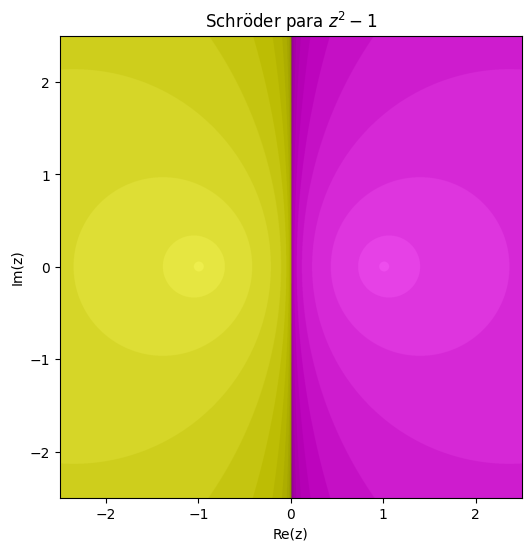

Imagen exportada a: img/schroeder_z2-1.png


In [7]:
import os

def schroeder_step_z2_minus_1(z):
    """Método de Schröder para p(z) = z^2 - 1"""
    z = np.asarray(z, dtype=np.complex128)
    pz = z**2 - 1
    dp = 2 * z  # p'(z) = 2z
    d2p = 2 + 0*z  # p''(z) = 2 (constante)
    
    lp = np.zeros_like(z)
    denom_lp = dp**2
    np.divide(pz * d2p, denom_lp, out=lp, where=denom_lp != 0)
    
    ratio = np.zeros_like(z)
    np.divide(pz, dp, out=ratio, where=dp != 0)
    
    correction = np.zeros_like(z)
    np.divide(ratio, 1 - lp, out=correction, where=(1 - lp) != 0)
    
    return z - correction

# Definimos raíces y parámetros de la malla para z^2 - 1
roots_z2 = np.array([1 + 0j, -1 + 0j], dtype=np.complex128)
labels_z2 = np.array([2, 1])  # Solo dos raíces
x_range_z2 = (-2.5, 2.5)
y_range_z2 = (-2.5, 2.5)
points_z2 = 1024*2
lim_z2 = 25

xs_z2, ys_z2, root_ids_z2, counts_z2, values_z2 = compute_basins(
    schroeder_step_z2_minus_1,
    roots_z2,
    labels_z2,
    x_range_z2,
    y_range_z2,
    points_z2,
    lim_z2,
)

print("Iteraciones máximas registradas (z^2-1):", counts_z2.max())

# Colores para 2 raíces (adaptado de colors_case2)
labels = values_z2.astype(int)
frac = np.modf(values_z2)[0]
pp = 0.4 * frac
colors_z2 = np.zeros(values_z2.shape + (3,), dtype=float)
mask2 = labels == 2
mask1 = labels == 1
if np.any(mask2):
    colors_z2[mask2] = cmyk_to_rgb(0.0, 0.6 + pp[mask2], 0.0, 2 * pp[mask2])  # Magenta para raíz 1
if np.any(mask1):
    colors_z2[mask1] = cmyk_to_rgb(0.0, 0.0, 0.6 + pp[mask1], 2 * pp[mask1])  # Amarillo para raíz -1

show_fractal(xs_z2, ys_z2, colors_z2, "Schröder para $z^2 - 1$")

# Crear carpeta img si no existe
os.makedirs('img', exist_ok=True)

# Exportar sin título pero con escalas en los ejes (sin etiquetas)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(colors_z2, origin='upper', extent=[xs_z2.min(), xs_z2.max(), ys_z2.min(), ys_z2.max()])
ax.set_xlabel('')  # Sin etiqueta en eje x
ax.set_ylabel('')  # Sin etiqueta en eje y
ax.tick_params(axis='both', which='both', length=5, width=1)  # Mostrar ticks
plt.savefig('img/schroeder_z2-1.png', dpi=300, bbox_inches='tight')
plt.close()

print("Imagen exportada a: img/schroeder_z2-1.png")

Iteraciones máximas registradas ((z-1)^2(z+1)): 47


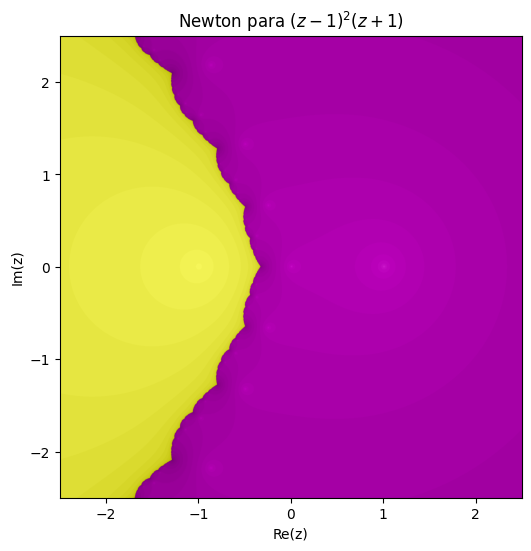

Imagen exportada a: img/newton_(z-1)^2(z+1).png


In [8]:
import os

def newton_step_z_minus_1_sq_z_plus_1(z):
    """Método de Newton para p(z) = (z-1)^2(z+1)"""
    z = np.asarray(z, dtype=np.complex128)
    # p(z) = (z-1)^2(z+1) = z^3 - z^2 - z + 1
    pz = (z - 1)**2 * (z + 1)
    # p'(z) = 2(z-1)(z+1) + (z-1)^2 = (z-1)(2(z+1) + (z-1)) = (z-1)(3z+1)
    dp = (z - 1) * (3*z + 1)
    
    update = np.zeros_like(z)
    np.divide(pz, dp, out=update, where=dp != 0)
    
    return z - update

# Definimos raíces y parámetros de la malla
# Raíces: z=1 (doble) y z=-1 (simple)
roots_cubic = np.array([1 + 0j, -1 + 0j], dtype=np.complex128)
labels_cubic = np.array([2, 1])  # Dos raíces distintas
x_range_cubic = (-2.5, 2.5)
y_range_cubic = (-2.5, 2.5)
points_cubic = 1024*2
lim_cubic = 50  # Más iteraciones por la raíz múltiple

xs_c, ys_c, root_ids_c, counts_c, values_c = compute_basins(
    newton_step_z_minus_1_sq_z_plus_1,
    roots_cubic,
    labels_cubic,
    x_range_cubic,
    y_range_cubic,
    points_cubic,
    lim_cubic,
)

print("Iteraciones máximas registradas ((z-1)^2(z+1)):", counts_c.max())

# Colores para 2 raíces
labels = values_c.astype(int)
frac = np.modf(values_c)[0]
pp = 0.4 * frac
colors_cubic = np.zeros(values_c.shape + (3,), dtype=float)
mask2 = labels == 2
mask1 = labels == 1
if np.any(mask2):
    colors_cubic[mask2] = cmyk_to_rgb(0.0, 0.6 + pp[mask2], 0.0, 2 * pp[mask2])  # Magenta para raíz 1 (doble)
if np.any(mask1):
    colors_cubic[mask1] = cmyk_to_rgb(0.0, 0.0, 0.6 + pp[mask1], 2 * pp[mask1])  # Amarillo para raíz -1

show_fractal(xs_c, ys_c, colors_cubic, "Newton para $(z-1)^2(z+1)$")

# Crear carpeta img si no existe
os.makedirs('img', exist_ok=True)

# Exportar sin título pero con escalas en los ejes (sin etiquetas)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(colors_cubic, origin='upper', extent=[xs_c.min(), xs_c.max(), ys_c.min(), ys_c.max()])
ax.set_xlabel('')  # Sin etiqueta en eje x
ax.set_ylabel('')  # Sin etiqueta en eje y
ax.tick_params(axis='both', which='both', length=5, width=1)  # Mostrar ticks
plt.savefig('img/newton_(z-1)^2(z+1).png', dpi=300, bbox_inches='tight')
plt.close()

print("Imagen exportada a: img/newton_(z-1)^2(z+1).png")